# Machine Learning and Big Data
## Predictive Analytics and Condition Monitoring of Industrial Equipment

### Competition Task - Skills Camp 2026

**Participant:** Naaol Raffisaa Daargee  
**Competence:** Machine Learning and Big Data  
**Dataset:** Industrial Pump Equipment Sensor Data  
**Target:** `anomaly`

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report, confusion_matrix

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("data.csv", sep=";")

print("Shape:", df.shape)
print("\nFirst 5 records:")
display(df.head())

print("\nLast 5 records:")
display(df.tail())

print("\nDataset information:")
df.info()

Shape: (1145, 11)

First 5 records:


,datetime,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,changepoint
0,2020-03-09 10:34:33,0.0271,0.0396,0.8713,0.0547,75.4955,25.8338,244.0910,32.0000,0.0000,0.0000
1,2020-03-09 10:34:34,0.0270,0.0388,1.3013,0.0547,75.5445,25.8408,224.1700,32.0000,0.0000,0.0000
2,2020-03-09 10:34:35,0.0268,0.0395,1.2845,0.3826,75.6607,25.8227,234.1570,32.9986,0.0000,0.0000
3,2020-03-09 10:34:36,0.0268,0.0386,1.3650,0.0547,75.5750,25.8262,229.9020,32.9986,0.0000,0.0000
4,2020-03-09 10:34:37,0.0264,0.0388,0.7918,0.0547,75.4351,25.8382,251.6970,32.0015,0.0000,0.0000



Last 5 records:


,datetime,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,changepoint
1140,2020-03-09 10:54:29,0.0267,0.0400,1.2674,0.0547,72.7882,25.6189,236.5980,31.0010,0.0000,0.0000
1141,2020-03-09 10:54:30,0.0274,0.0390,1.2839,0.0547,72.7927,25.6224,223.6830,32.0000,0.0000,0.0000
1142,2020-03-09 10:54:31,0.0263,0.0393,1.1388,0.0547,72.7045,25.6224,236.1860,31.9990,0.0000,0.0000
1143,2020-03-09 10:54:32,0.0273,0.0402,1.0976,0.3826,72.7763,25.6212,241.6850,31.0010,0.0000,0.0000
1144,2020-03-09 10:54:33,0.0267,0.0388,1.3388,0.0547,72.7372,25.6182,231.0730,31.9990,0.0000,0.0000



Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1145 entries, 0 to 1144
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   datetime             1145 non-null   str    
 1   Accelerometer1RMS    1145 non-null   float64
 2   Accelerometer2RMS    1145 non-null   float64
 3   Current              1145 non-null   float64
 4   Pressure             1145 non-null   float64
 5   Temperature          1145 non-null   float64
 6   Thermocouple         1145 non-null   float64
 7   Voltage              1145 non-null   float64
 8   Volume Flow RateRMS  1145 non-null   float64
 9   anomaly              1145 non-null   float64
 10  changepoint          1145 non-null   float64
dtypes: float64(10), str(1)
memory usage: 98.5 KB


Missing values:


datetime               0
Accelerometer1RMS      0
Accelerometer2RMS      0
Current                0
Pressure               0
Temperature            0
Thermocouple           0
Voltage                0
Volume Flow RateRMS    0
anomaly                0
changepoint            0
dtype: int64


Descriptive statistics:


,datetime,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,anomaly,changepoint
count,1145,1145.0000,1145.0000,1145.0000,1145.0000,1145.0000,1145.0000,1145.0000,1145.0000,1145.0000,1145.0000
mean,2020-03-09 10:44:32.850655,0.0269,0.0400,0.9790,0.0745,73.7135,25.7400,231.4135,31.5668,0.3511,0.0035
min,2020-03-09 10:34:33,0.0258,0.0376,0.3755,-0.9291,71.0004,25.6111,203.7380,30.0000,0.0000,0.0000
25%,2020-03-09 10:39:33,0.0266,0.0394,0.7357,0.0547,72.7892,25.6900,225.7680,31.0000,0.0000,0.0000
50%,2020-03-09 10:44:33,0.0269,0.0400,0.9972,0.0547,73.9086,25.7459,231.2930,32.0000,0.0000,0.0000
75%,2020-03-09 10:49:32,0.0271,0.0406,1.2066,0.0547,74.2706,25.7819,237.5400,32.0000,1.0000,0.0000
max,2020-03-09 10:54:33,0.0279,0.0534,1.5962,1.0385,76.2801,25.9240,254.5200,33.0000,1.0000,1.0000
std,NaN,0.0003,0.0010,0.2775,0.2500,1.3331,0.0634,10.7641,0.7600,0.4775,0.0590



Anomaly distribution:


anomaly
0    743
1    402
Name: count, dtype: int64


Changepoint distribution:


changepoint
0    1141
1       4
Name: count, dtype: int64


Outlier counts:


Pressure               480
Voltage                 37
Accelerometer2RMS       19
Accelerometer1RMS        5
Thermocouple             2
Current                  0
Temperature              0
Volume Flow RateRMS      0
dtype: int64

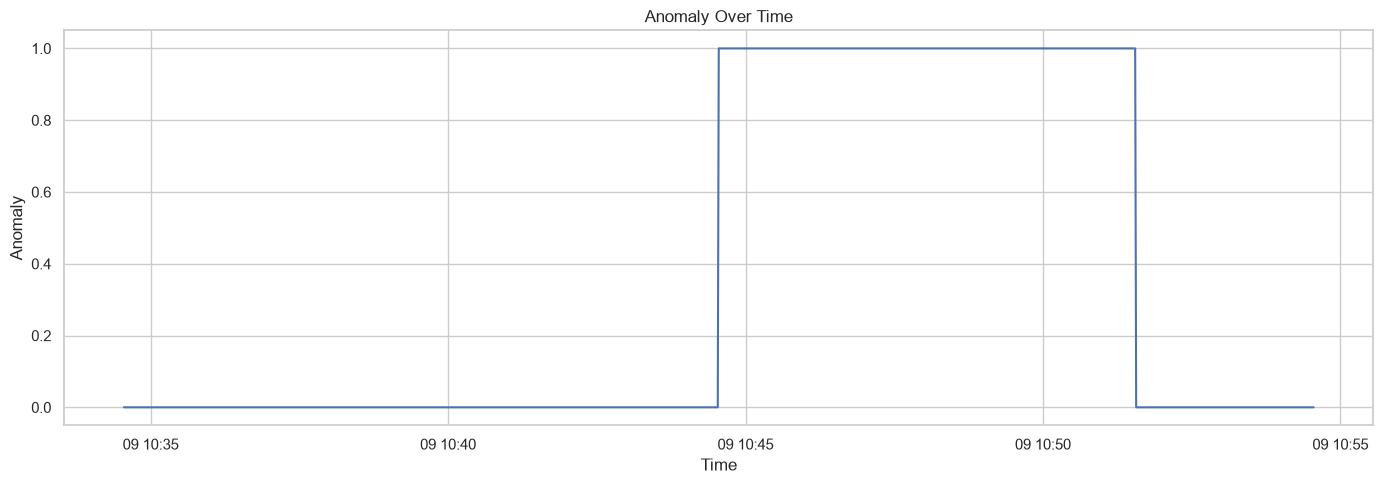

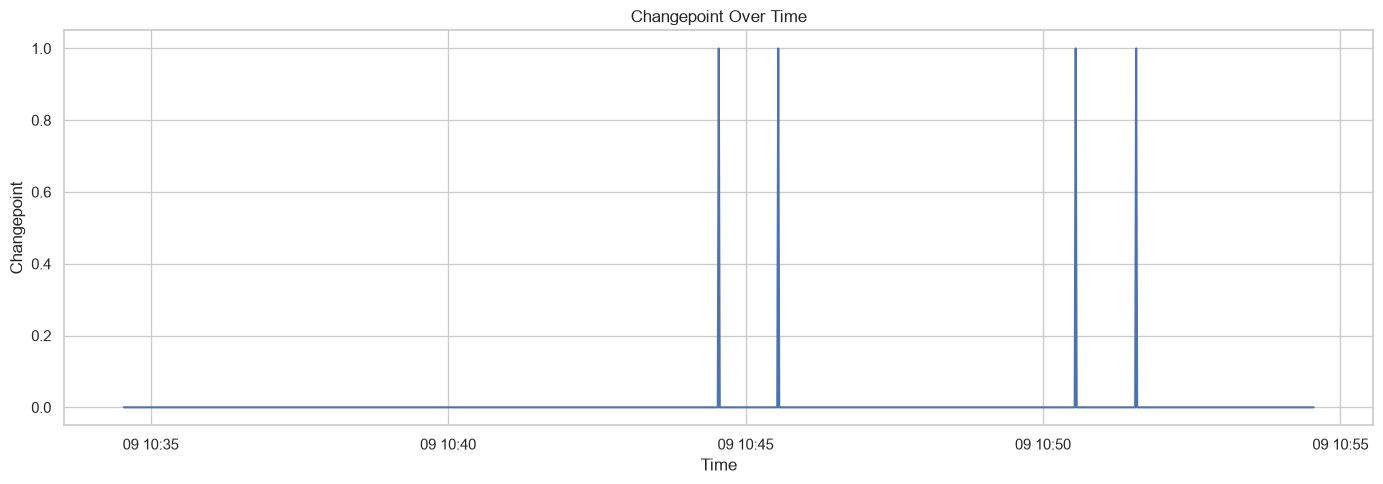

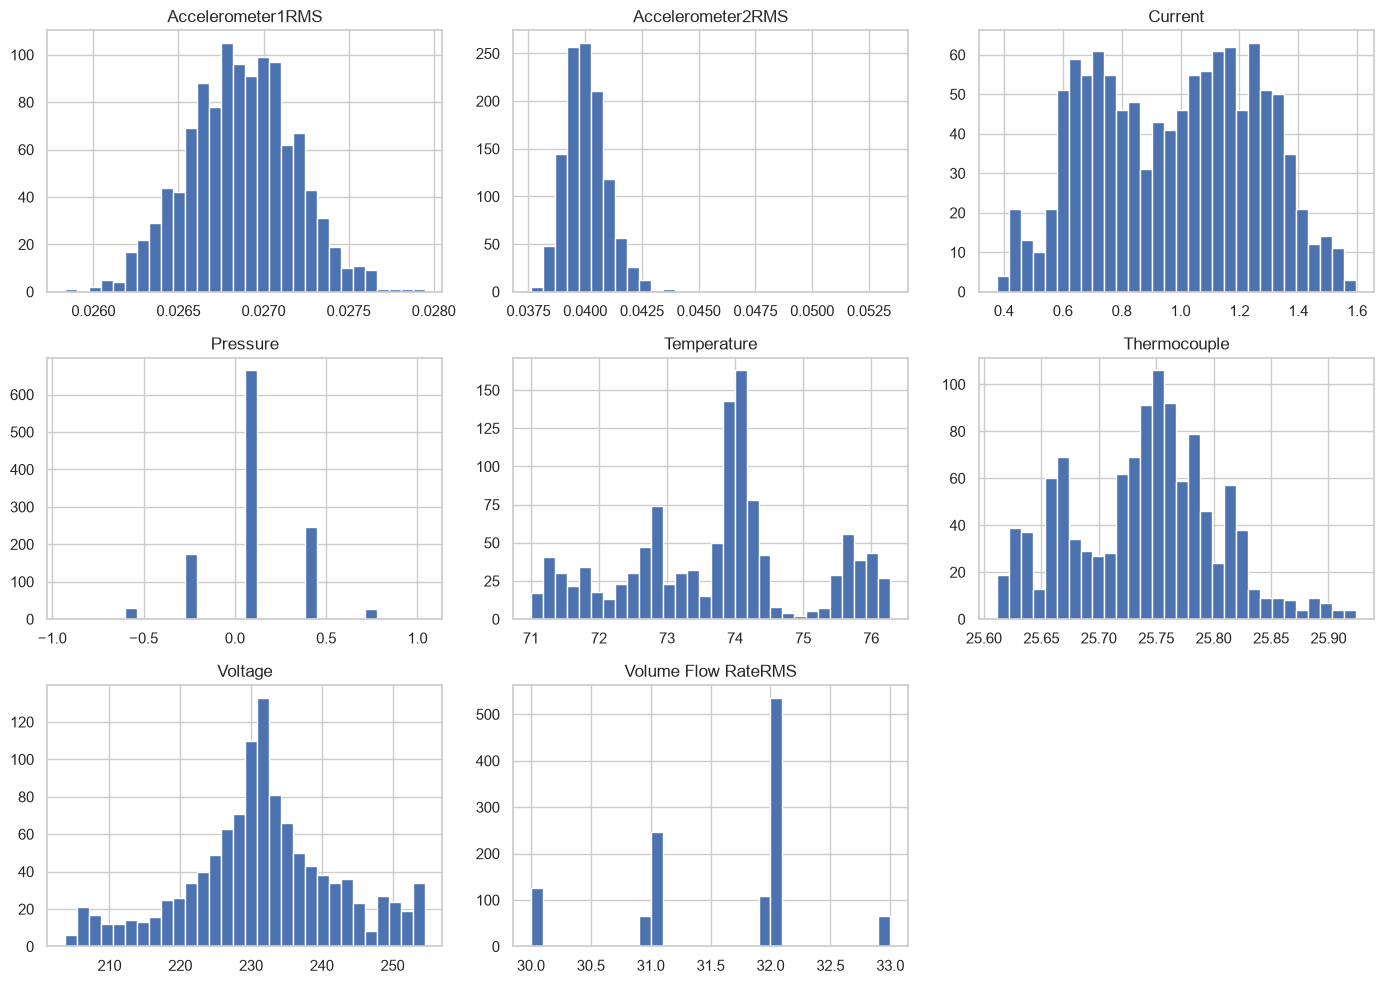

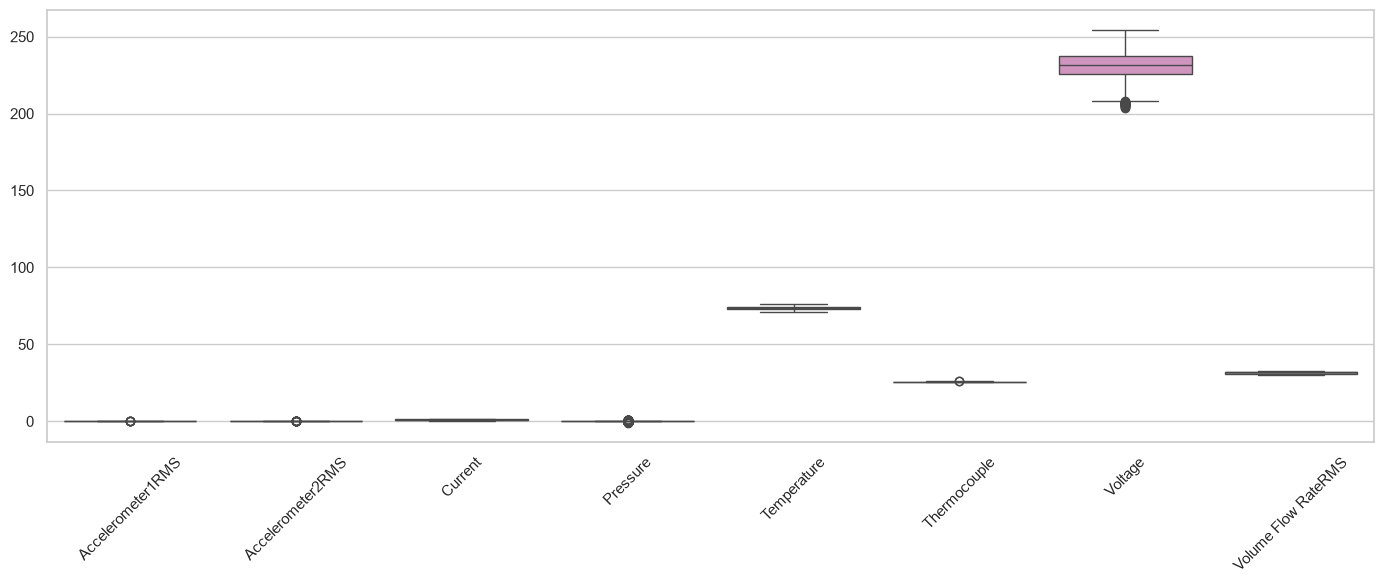

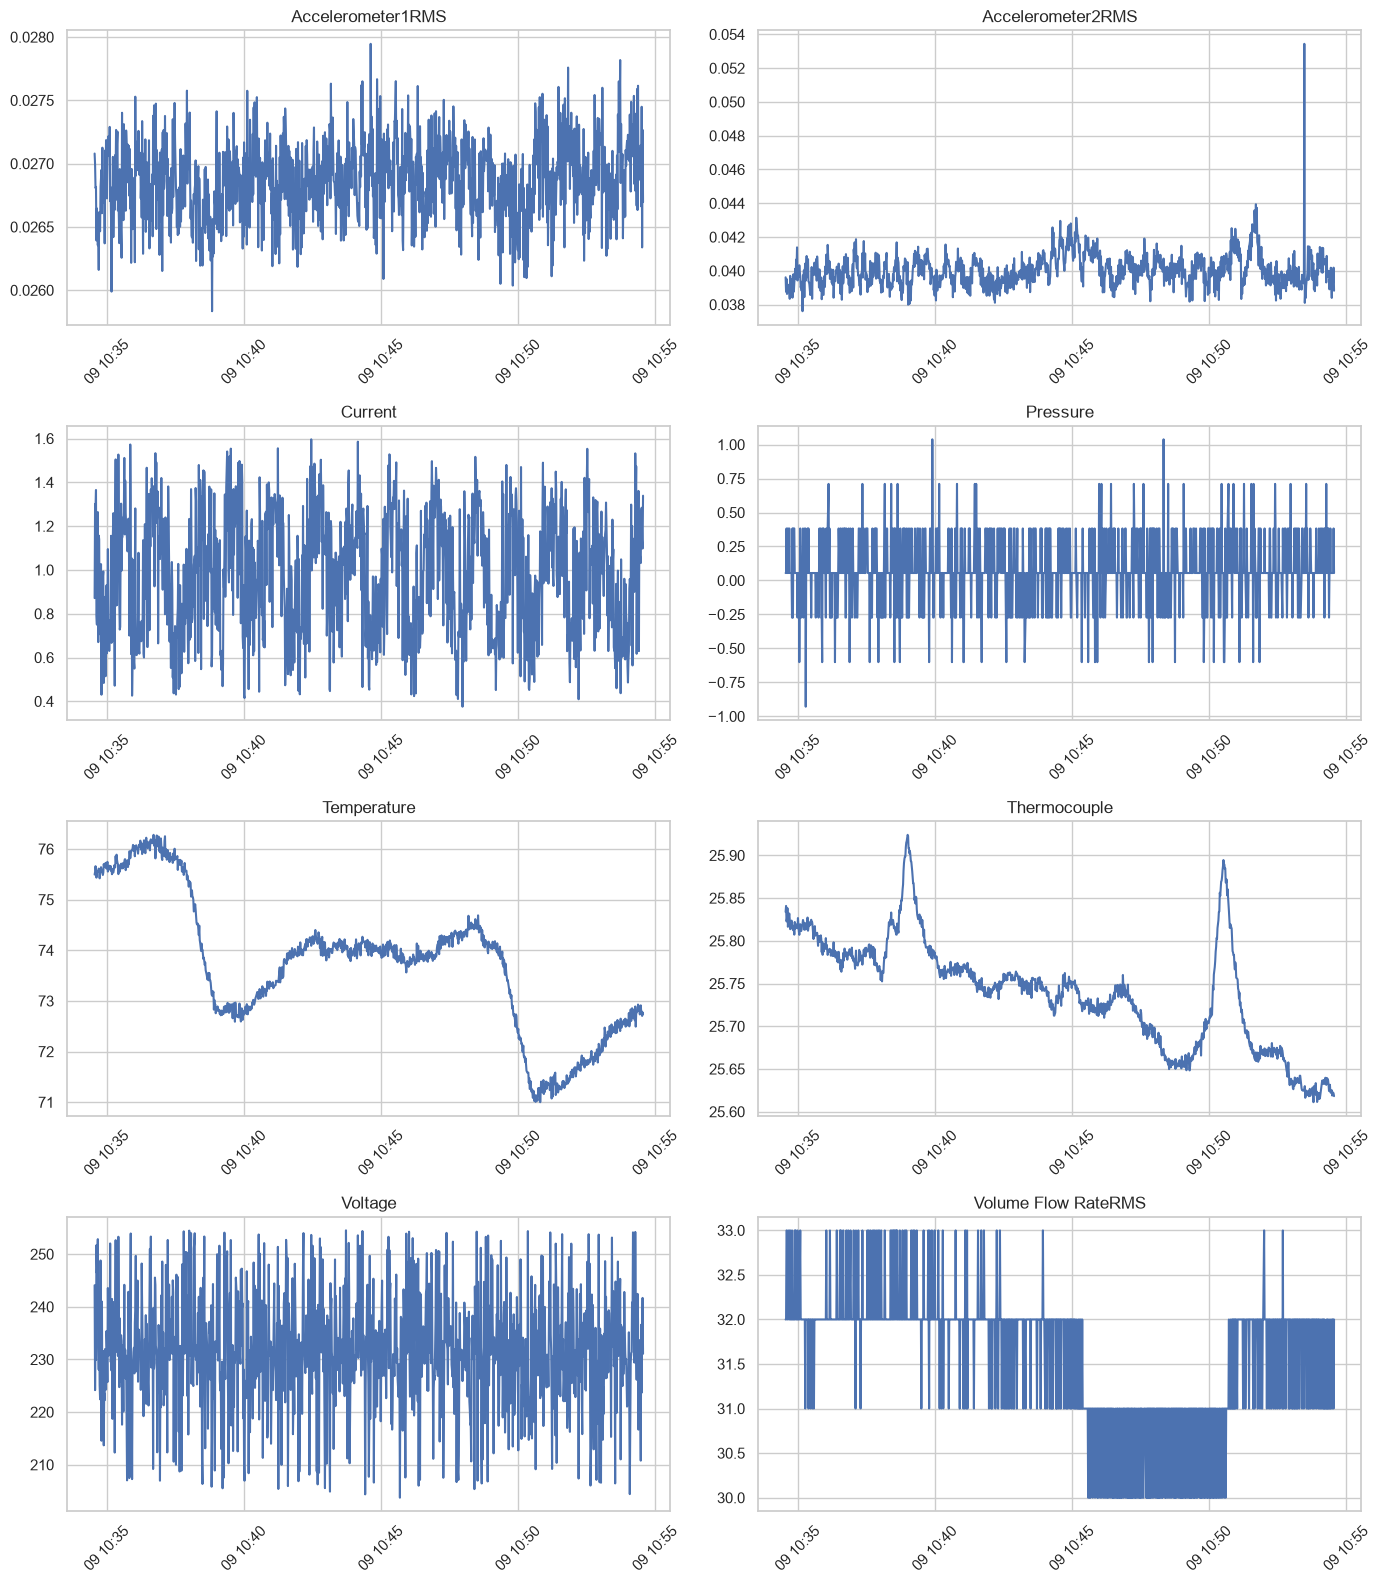

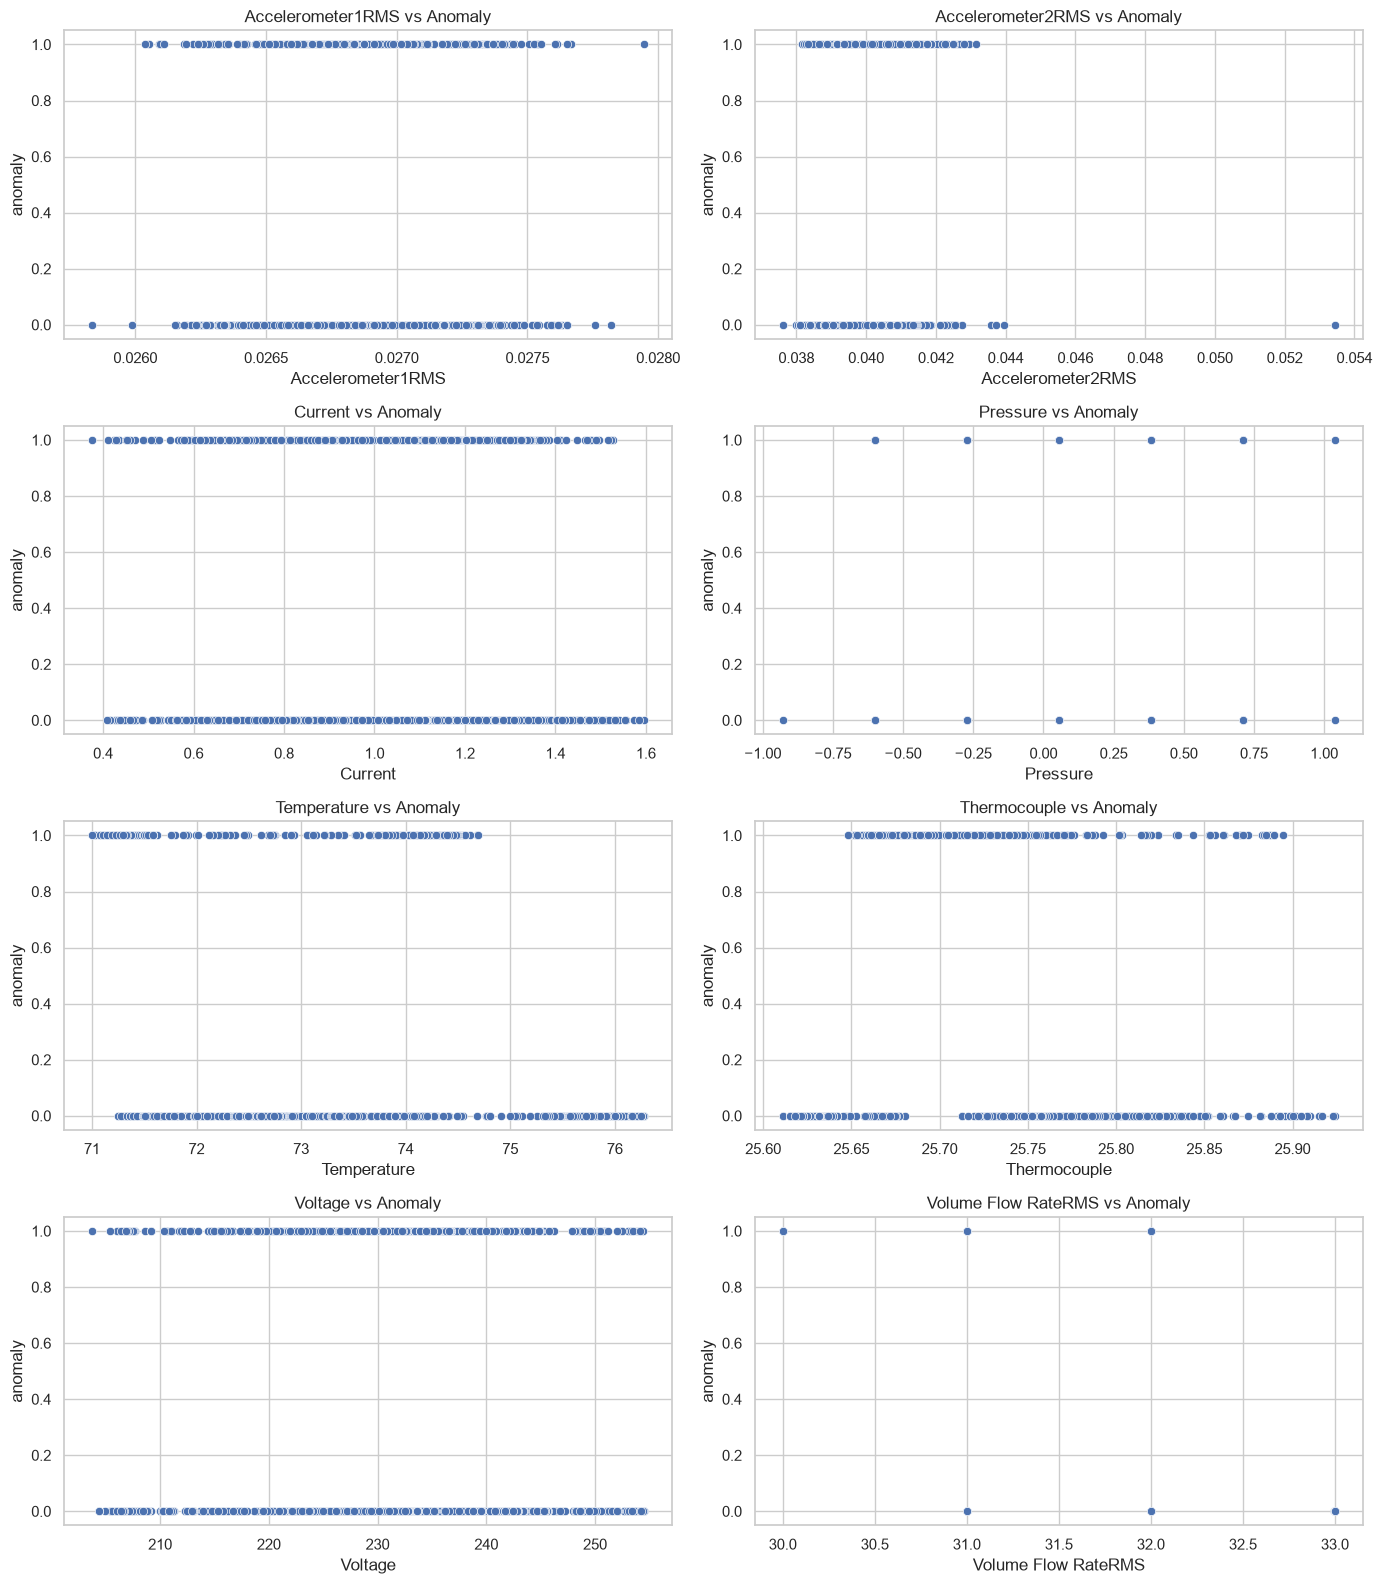

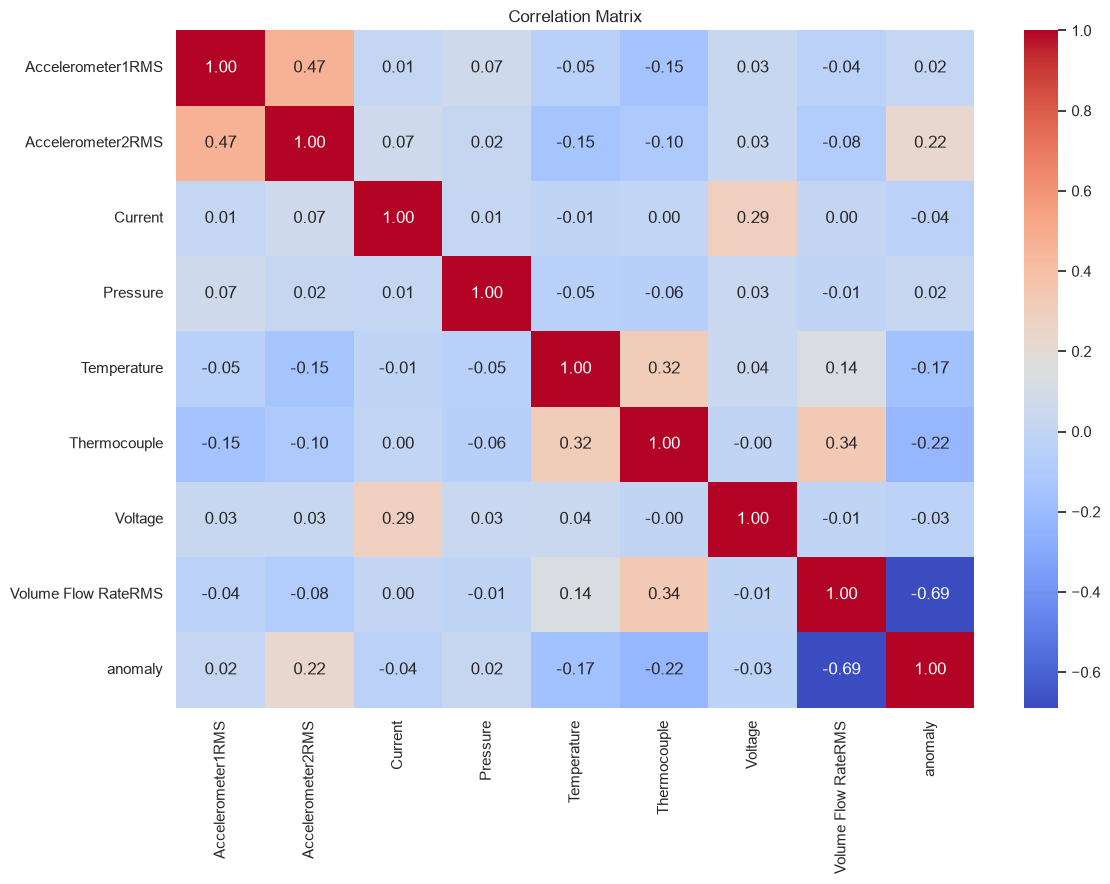

Highly correlated feature pairs:


In [4]:
df["datetime"] = pd.to_datetime(df["datetime"])
df["anomaly"] = df["anomaly"].astype(int)
df["changepoint"] = df["changepoint"].astype(int)

print("Missing values:")
display(df.isnull().sum())

print("\nDescriptive statistics:")
display(df.describe())

print("\nAnomaly distribution:")
display(df["anomaly"].value_counts())

print("\nChangepoint distribution:")
display(df["changepoint"].value_counts())

numeric_features = df.select_dtypes(include=np.number).columns.drop(["anomaly", "changepoint"])

print("\nOutlier counts:")
outlier_counts = {}
for col in numeric_features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_counts[col] = ((df[col] < lower) | (df[col] > upper)).sum()

display(pd.Series(outlier_counts).sort_values(ascending=False))

plt.figure(figsize=(14, 5))
plt.plot(df["datetime"], df["anomaly"])
plt.title("Anomaly Over Time")
plt.xlabel("Time")
plt.ylabel("Anomaly")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(df["datetime"], df["changepoint"])
plt.title("Changepoint Over Time")
plt.xlabel("Time")
plt.ylabel("Changepoint")
plt.tight_layout()
plt.show()

df[numeric_features].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.boxplot(data=df[numeric_features])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for ax, col in zip(axes.ravel(), numeric_features):
    ax.plot(df["datetime"], df[col])
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for ax, col in zip(axes.ravel(), numeric_features):
    sns.scatterplot(data=df, x=col, y="anomaly", ax=ax)
    ax.set_title(f"{col} vs Anomaly")
plt.tight_layout()
plt.show()

corr = df[numeric_features.tolist() + ["anomaly"]].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

print("Highly correlated feature pairs:")
for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) >= 0.80:
            print(corr.columns[i], "-", corr.columns[j], ":", round(corr.iloc[i, j], 3))

In [5]:
model_df = df.drop(columns=["datetime", "changepoint"]).copy()

X = model_df.drop(columns=["anomaly"])
y = model_df["anomaly"]

split_index = int(len(model_df) * 0.70)

X_train = X.iloc[:split_index].copy()
X_test = X.iloc[split_index:].copy()
y_train = y.iloc[:split_index].copy()
y_test = y.iloc[split_index:].copy()

models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ]),
    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(random_state=42, class_weight="balanced"))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"))
    ]),
    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingClassifier(random_state=42))
    ])
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    results.append({
        "Model": name,
        "F1": f1_score(y_test, predictions, zero_division=0),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0)
    })

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)

display(results_df)

,Model,F1,Precision,Recall
2,Random Forest,0.8078,0.9254,0.7168
3,Gradient Boosting,0.6835,0.9048,0.5491
1,Decision Tree,0.6124,0.4864,0.8266
0,Logistic Regression,0.5618,0.4408,0.7746


In [6]:
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(random_state=42, class_weight="balanced"))
])

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
final_predictions = best_model.predict(X_test)

final_f1 = f1_score(y_test, final_predictions, zero_division=0)
final_precision = precision_score(y_test, final_predictions, zero_division=0)
final_recall = recall_score(y_test, final_predictions, zero_division=0)

print("Best parameters:")
print(grid_search.best_params_)

print("\nFinal model performance:")
print("F1-score:", round(final_f1, 4))
print("Precision:", round(final_precision, 4))
print("Recall:", round(final_recall, 4))

print("\nClassification report:")
print(classification_report(y_test, final_predictions, zero_division=0))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, final_predictions))

train_output = X_train.copy()
train_output["anomaly"] = y_train
train_output.to_csv("train.csv", index=False)

test_output = X_test.copy()
test_output["anomaly"] = y_test
test_output.to_csv("test.csv", index=False)

joblib.dump(best_model, "best_random_forest_model.pkl")

print("\nSaved:")
print("train.csv")
print("test.csv")
print("best_random_forest_model.pkl")

Best parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Final model performance:
F1-score: 0.7027
Precision: 0.8455
Recall: 0.6012

Classification report:
              precision    recall  f1-score   support

           0       0.69      0.89      0.78       171
           1       0.85      0.60      0.70       173

    accuracy                           0.74       344
   macro avg       0.77      0.75      0.74       344
weighted avg       0.77      0.74      0.74       344


Confusion matrix:
[[152  19]
 [ 69 104]]

Saved:
train.csv
test.csv
best_random_forest_model.pkl


In [7]:
final_results = pd.DataFrame({
    "Metric": ["F1-score", "Precision", "Recall"],
    "Score": [final_f1, final_precision, final_recall]
})

display(final_results)

,Metric,Score
0,F1-score,0.7027
1,Precision,0.8455
2,Recall,0.6012


In [8]:
feature_corr = X.corr().abs()

upper = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))

target_corr = X.join(y).corr()["anomaly"].drop("anomaly").abs()

features_to_drop = set()

for column in upper.columns:
    correlated = upper[column][upper[column] >= 0.80].index
    for row in correlated:
        if target_corr[row] < target_corr[column]:
            features_to_drop.add(row)
        else:
            features_to_drop.add(column)

features_to_drop = sorted(features_to_drop)

print("Features removed because of high multicollinearity:")
print(features_to_drop)

X_processed = X.drop(columns=features_to_drop)

X_train_processed = X_processed.iloc[:split_index].copy()
X_test_processed = X_processed.iloc[split_index:].copy()

processed_models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ]),
    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(random_state=42, class_weight="balanced"))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"))
    ]),
    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", HistGradientBoostingClassifier(random_state=42))
    ])
}

processed_results = []

for name, model in processed_models.items():
    model.fit(X_train_processed, y_train)
    predictions = model.predict(X_test_processed)

    processed_results.append({
        "Model": name,
        "F1": f1_score(y_test, predictions, zero_division=0),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0)
    })

processed_results_df = pd.DataFrame(processed_results).sort_values("F1", ascending=False)

display(processed_results_df)

Features removed because of high multicollinearity:
[]


,Model,F1,Precision,Recall
2,Random Forest,0.8078,0.9254,0.7168
3,Gradient Boosting,0.6835,0.9048,0.5491
1,Decision Tree,0.6124,0.4864,0.8266
0,Logistic Regression,0.5618,0.4408,0.7746


## Conclusion on Data Exploration

The dataset comprises 1145 records and 11 variables. The data has no missing values. The data has many outliers, which were left in the set, as they could represent malfunctioning equipment. The target was defined as Anomaly and changepoint was dropped due to high correlation with the target variable. No features were highly correlated, so collinearity was not an issue.

## Best Model

Four models were compared using a 70/30 time series split. The best result was provided by the Random Forest classifier, with an F1-score of 0.8078, precision of 0.9254, and recall of 0.7168.

## Hyperparameter Optimization

Random Forest was optimized using **GridSearchCV with 5-fold cross-validation**. The selected parameters were:

* `n_estimators = 100`
* `max_depth = None`
* `min_samples_split = 5`
* `min_samples_leaf = 2`

The final model achieved an **F1-score of 0.7027**, **precision of 0.8455**, and **recall of 0.6012** on the test set. Although the F1-score was lower than the best validation result, this model was retained because it followed the required procedure.

## Final Conclusion

Overall, I explored the equipment test data, compared four classification models, and optimized the selected Random Forest model. The final model provides a basis for detecting anomalous equipment behavior. The final model, datasets, code, and report are available in the final directory.